# Matrix Network Analysis

This notebook present the result of performing network analysis on the Matrix testbed. It produces plots, and tables that can be used for further analysis and presentation.

Author: Kananelo Chabeli

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

In [26]:
plt.rcParams.update(
    {"font.family": "serif","font.size": 6,"axes.labelsize": 5,"axes.titlesize": 5,"xtick.labelsize": 4,
        "ytick.labelsize": 4,"legend.fontsize": 4,"figure.titlesize": 7,"text.usetex": False,  # Set to True if local LaTeX compiler is configured
    }
)

## 1. Define File Paths to Generated CSV files

In [4]:
#Define the Constants (File Names)

# CSV file storing Latency dataset for Scada <--> Middleware network boundary
# The columns in the file are: device,protocol,sample_index,latency_ms
SCADA_MIDDLEWARE_LATENCY_CSV = r"..\data\scada_middleware_latency.csv"    

# CSV File storing latency dataset for Middleware <--> PLCs network boundary
# The columns in the dataset: device,protocol,sample_index,latency_ms
PLCS_MIDDLEWARE_LATENCY_CSV = r"..\data\middleware_latency.csv"

# CSV File storing latency dataset for Inter-PLC network boundary ( Peer-to-peer network boundary)
# The columns in the dataset: Boundary,Protocol,Src_IP,Dst_IP,RTT_ms
INTER_PLC_LATENCY_CSV = r"..\data\inter_plc_latency.csv"

# CSV File storing throughput per protocol for all network boundaries of the Matrix Testbed.
# The columns in the datatset are: Boundary,Protocol,Time_Bin_Start_Sec,Bytes,Packets,Bytes_per_Sec,Packets_per_Sec
MATRIX_THROUGHPUT_CSV = r"..\data\throughput.csv"

#CSV File storing the Packet Overhead(Frame vs TCP payload) dataset for different protocols on different boundaries
#The columns in the dataset are: Boundary,Protocol,Frame_Bytes,TCP_Payload_Bytes,Overhead_Bytes,Overhead_Ratio
MATRIX_PACKET_OVERHEAD_CSV = r"..\data\protocol_overhead.csv"


## 2. Load CSV Files

In [5]:
def load_csv(filepath):
    """
        Read CSV file and returns the result  DataFrame or None if file not found.

        Args:
            filepath(str): The path of the csv file to read.
        Returns:
            pd.DataFrame | None 
    """
    if not os.path.exists(filepath):
        print(f"Could not find {filepath}")
        return None
    df = pd.read_csv(filepath)
    print(f"Loaded {len(df)} rows from {filepath}")
    print(df.head())
    return df

In [6]:
SCADA_MIDDLEWARE_LATENCY_DF = load_csv(SCADA_MIDDLEWARE_LATENCY_CSV)

Loaded 500 rows from ..\data\scada_middleware_latency.csv
                   device protocol  sample_index  latency_ms
0  RPi Middleware<->SCADA   OPC UA             0      8.8951
1  RPi Middleware<->SCADA   OPC UA             1      9.5382
2  RPi Middleware<->SCADA   OPC UA             2      5.6340
3  RPi Middleware<->SCADA   OPC UA             3      5.0111
4  RPi Middleware<->SCADA   OPC UA             4      4.9327


In [7]:
PLCS_MIDDLEWARE_LATENCY_DF = load_csv(PLCS_MIDDLEWARE_LATENCY_CSV)

Loaded 1500 rows from ..\data\middleware_latency.csv
                   device     protocol  sample_index  latency_ms
0  Allen-Bradley Micro820  EtherNet/IP             0    6.994583
1  Allen-Bradley Micro820  EtherNet/IP             1    5.936406
2  Allen-Bradley Micro820  EtherNet/IP             2    5.025469
3  Allen-Bradley Micro820  EtherNet/IP             3    6.142031
4  Allen-Bradley Micro820  EtherNet/IP             4    5.430365


In [8]:
INTER_PLC_LATENCY_DF = load_csv(INTER_PLC_LATENCY_CSV)

Loaded 90281 rows from ..\data\inter_plc_latency.csv
                          Boundary    Protocol         Src_IP         Dst_IP  \
0  TM221 <-> Micro820 (Modbus TCP)  Modbus TCP  192.168.50.20  192.168.50.50   
1  TM221 <-> Micro820 (Modbus TCP)  Modbus TCP  192.168.50.50  192.168.50.20   
2  TM221 <-> Micro820 (Modbus TCP)  Modbus TCP  192.168.50.20  192.168.50.50   
3  TM221 <-> Micro820 (Modbus TCP)  Modbus TCP  192.168.50.50  192.168.50.20   
4  TM221 <-> Micro820 (Modbus TCP)  Modbus TCP  192.168.50.20  192.168.50.50   

       RTT_ms  
0    3.465176  
1    2.221823  
2    3.168344  
3  191.426992  
4    4.114866  


In [9]:
MATRIX_THROUGHPUT_DF = load_csv(MATRIX_THROUGHPUT_CSV)

Loaded 3589 rows from ..\data\throughput.csv
                                 Boundary Protocol  Time_Bin_Start_Sec  Bytes  \
0  Ignition SCADA <-> Middleware (OPC UA)   OPC UA                 0.0    851   
1  Ignition SCADA <-> Middleware (OPC UA)   OPC UA                 1.0    888   
2  Ignition SCADA <-> Middleware (OPC UA)   OPC UA                 2.0    851   
3  Ignition SCADA <-> Middleware (OPC UA)   OPC UA                 3.0    851   
4  Ignition SCADA <-> Middleware (OPC UA)   OPC UA                 4.0   1258   

   Packets  Bytes_per_Sec  Packets_per_Sec  
0        6          851.0              6.0  
1        6          888.0              6.0  
2        6          851.0              6.0  
3        6          851.0              6.0  
4       10         1258.0             10.0  


In [10]:
MATRIX_PACKET_OVERHEAD_DF = load_csv(MATRIX_PACKET_OVERHEAD_CSV)

Loaded 123222 rows from ..\data\protocol_overhead.csv
                            Boundary    Protocol  Frame_Bytes  \
0  Middleware <-> TM221 (Modbus TCP)  Modbus TCP           66   
1  Middleware <-> TM221 (Modbus TCP)  Modbus TCP           65   
2    TM221 <-> Micro820 (Modbus TCP)  Modbus TCP           66   
3  Middleware <-> TM221 (Modbus TCP)  Modbus TCP           66   
4  Middleware <-> TM221 (Modbus TCP)  Modbus TCP           66   

   TCP_Payload_Bytes  Overhead_Bytes  Overhead_Ratio  
0                 12              54        0.818182  
1                 11              54        0.830769  
2                 12              54        0.818182  
3                 12              54        0.818182  
4                 12              54        0.818182  


## 3.MATRIX LATENCY RESULTS Analysis

### 3.1 Combine all DataFrames into a single object

In [13]:
# 1. Prepare DataFrame 1
df1_prep = SCADA_MIDDLEWARE_LATENCY_DF.copy()
df1_prep['Boundary'] = 'SCADA <--> Middleware'
df1_prep = df1_prep.rename(columns={'protocol': 'Protocol', 'latency_ms': 'Latency_ms'})
df1_prep = df1_prep[['Boundary', 'Protocol', 'Latency_ms']]

# 2. Prepare DataFrame 2
df2_prep = PLCS_MIDDLEWARE_LATENCY_DF.copy()
df2_prep['Boundary'] = 'Middleware <--> PLCs'
df2_prep = df2_prep.rename(columns={'protocol': 'Protocol', 'latency_ms': 'Latency_ms'})
df2_prep = df2_prep[['Boundary', 'Protocol', 'Latency_ms']]

# 3. Prepare DataFrame 3
df3_prep = INTER_PLC_LATENCY_DF.copy()
df3_prep = df3_prep.rename(columns={'RTT_ms': 'Latency_ms'})
df3_prep = df3_prep[['Boundary', 'Protocol', 'Latency_ms']]

# 4. Combine all three DataFrames into one
DF_MATRIX_LATENCY = pd.concat([df1_prep, df2_prep, df3_prep], ignore_index=True)

# Verify the combined result
print(DF_MATRIX_LATENCY.head())
print("\nSample count per boundary:")
print(DF_MATRIX_LATENCY['Boundary'].value_counts());

                Boundary Protocol  Latency_ms
0  SCADA <--> Middleware   OPC UA      8.8951
1  SCADA <--> Middleware   OPC UA      9.5382
2  SCADA <--> Middleware   OPC UA      5.6340
3  SCADA <--> Middleware   OPC UA      5.0111
4  SCADA <--> Middleware   OPC UA      4.9327

Sample count per boundary:
Boundary
S7-1200 <-> Micro820 (Modbus TCP)    78285
TM221 <-> Micro820 (Modbus TCP)      11996
Middleware <--> PLCs                  1500
SCADA <--> Middleware                  500
Name: count, dtype: int64


### 3.2 Plot the Empirical Commulative Distribution Function

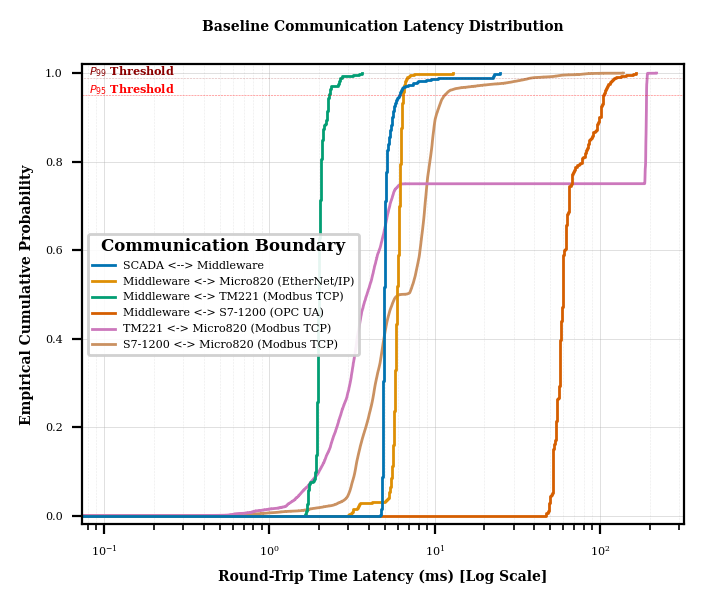

In [39]:
fig, ax = plt.subplots(figsize=(3.5, 3.0), dpi=200)
# Define a high-contrast palette suitable for both color and grayscale printing
n_boundaries = DF_MATRIX_LATENCY["Boundary"].nunique()
palette = sns.color_palette("colorblind", n_colors=n_boundaries+2)
df_plot = DF_MATRIX_LATENCY.copy()

def refine_boundary(row):
    # If using IP/Protocol metadata to separate the generic boundary:
    if row["Boundary"] == "Middleware <--> PLCs":
        if row["Protocol"] == "OPC UA":
            return "Middleware <-> S7-1200 (OPC UA)"
        elif row["Protocol"] == "EtherNet/IP":
            return "Middleware <-> Micro820 (EtherNet/IP)"
        elif row["Protocol"] == "Modbus TCP":
            return "Middleware <-> TM221 (Modbus TCP)"
    return row["Boundary"]

df_plot["Boundary"] = df_plot.apply(refine_boundary, axis=1)

sns.ecdfplot(data=df_plot,x="Latency_ms",hue="Boundary",
             palette=palette,linewidth=1.0,ax=ax,)

# Logarithmic X-axis is recommended due to multi-decade latency range across tiers
ax.set_xscale("log")
ax.set_xlabel("Round-Trip Time Latency (ms) [Log Scale]", fontweight="bold")
ax.set_ylabel("Empirical Cumulative Probability", fontweight="bold")
ax.set_title("Baseline Communication Latency Distribution", pad=12, fontweight="bold")

# Set Y-axis bounds explicitly between 0 and 1
ax.set_ylim(-0.02, 1.02)

# Major and minor grid lines for precise quantile reading (P50, P95, P99)
ax.grid(True, which="major", linestyle="-", linewidth=0.2, alpha=0.7)
ax.grid(True, which="minor", linestyle=":", linewidth=0.2, alpha=0.5)

# Add horizontal reference lines for P95 and P99 threshold identification
ax.axhline(0.95, color="red", linestyle="--", linewidth=0.2, alpha=0.6)
ax.text(ax.get_xlim()[0] * 1.1,0.955,"$P_{95}$ Threshold",
        color="red",fontsize=4,fontweight="bold",)

ax.axhline(0.99, color="darkred", linestyle=":", linewidth=0.2, alpha=0.6)
ax.text(ax.get_xlim()[0] * 1.1,0.995,"$P_{99}$ Threshold",
        color="darkred",fontsize=4,fontweight="bold",)

# 5. LEGEND & LAYOUT OPTIMIZATION

sns.move_legend(ax,"center left",frameon=True,facecolor="white",framealpha=0.9,
                title="Communication Boundary",title_fontproperties={"weight": "bold", "size": 6},)

plt.tight_layout()

# Save vector PDF for IEEE/ACM paper insertion and high-resolution PNG for previews
#plt.savefig("fig_matrix_latency_ecdf.pdf", format="pdf", bbox_inches="tight")
plt.savefig("fig_matrix_latency_ecdf.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [44]:
def calculate_ecdf_summary(df, boundary_col="Boundary", latency_col="Latency_ms"):
    """
    Computes key ECDF latency metrics (in ms) per communication boundary.
    """
    summary = []
    
    for boundary, group in df.groupby(boundary_col):
        latencies = group[latency_col].dropna().values
        
        summary.append({
            "Communication Boundary": boundary,
            "Count": len(latencies),
            "Min (ms)": np.min(latencies),
            "Median / P50 (ms)": np.percentile(latencies, 50),
            "P95 Threshold (ms)": np.percentile(latencies, 95),
            "P99 Threshold (ms)": np.percentile(latencies, 99),
            "Max (ms)": np.max(latencies),
            "Std Dev": np.std(latencies)
        })
    
    # Convert to formatted DataFrame
    summary_df = pd.DataFrame(summary)
    summary_df = summary_df.sort_values(by="Median / P50 (ms)").reset_index(drop=True)
    
    return summary_df

In [45]:
summary_df = calculate_ecdf_summary(df_plot)

In [46]:
summary_df.to_csv(r"..\data\latency_summary_table.csv")

In [47]:
summary_df

,Communication Boundary,Count,Min (ms),Median / P50 (ms),P95 Threshold (ms),P99 Threshold (ms),Max (ms),Std Dev
0,Middleware <-> TM221 (Modbus TCP),500,1.642239,1.988333,2.297421,2.710796,3.611406,0.193346
1,TM221 <-> Micro820 (Modbus TCP),11996,0.200987,3.892303,191.068470,192.781782,219.950438,80.739226
2,SCADA <--> Middleware,500,4.643600,4.965150,6.084140,13.804695,24.747400,1.907018
3,Middleware <-> Micro820 (EtherNet/IP),500,2.985469,5.934323,6.433073,6.810497,12.986615,0.634262
4,S7-1200 <-> Micro820 (Modbus TCP),78285,0.108242,6.320477,11.486673,40.011101,138.602495,7.226272
5,Middleware <-> S7-1200 (OPC UA),500,46.797917,59.938906,104.847401,122.130375,164.119844,18.529690


## Network Throughput Analysis

In [48]:
MATRIX_THROUGHPUT_DF["Avg_Packet_Size"] = MATRIX_THROUGHPUT_DF["Bytes"] / MATRIX_THROUGHPUT_DF["Packets"]

In [50]:
boundaries = MATRIX_THROUGHPUT_DF["Boundary"].unique()
palette = sns.color_palette("tab10", n_colors=len(boundaries))
color_map = dict(zip(boundaries, palette))

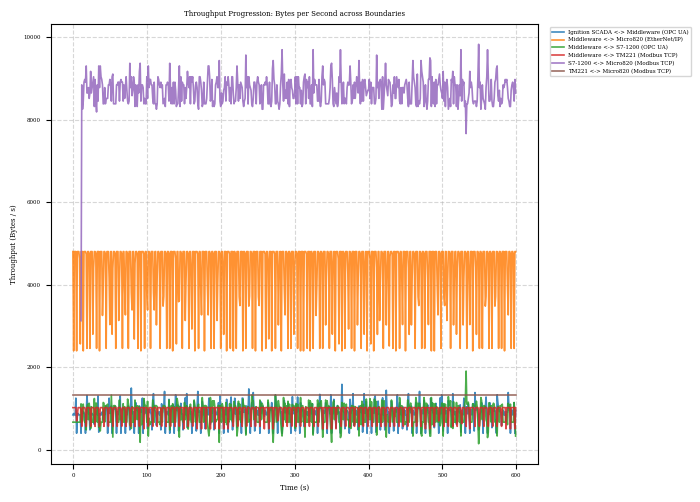

In [52]:
plt.figure(figsize=(7, 5))
for boundary, group in MATRIX_THROUGHPUT_DF.groupby("Boundary"):
    plt.plot(
        group["Time_Bin_Start_Sec"],
        group["Bytes_per_Sec"],
        label=boundary,
        color=color_map[boundary],
        linewidth=1.2,
        alpha=0.85,
    )

plt.title("Throughput Progression: Bytes per Second across Boundaries")
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Bytes / s)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig("throughput_bytes_per_sec.png", dpi=300)
plt.show()

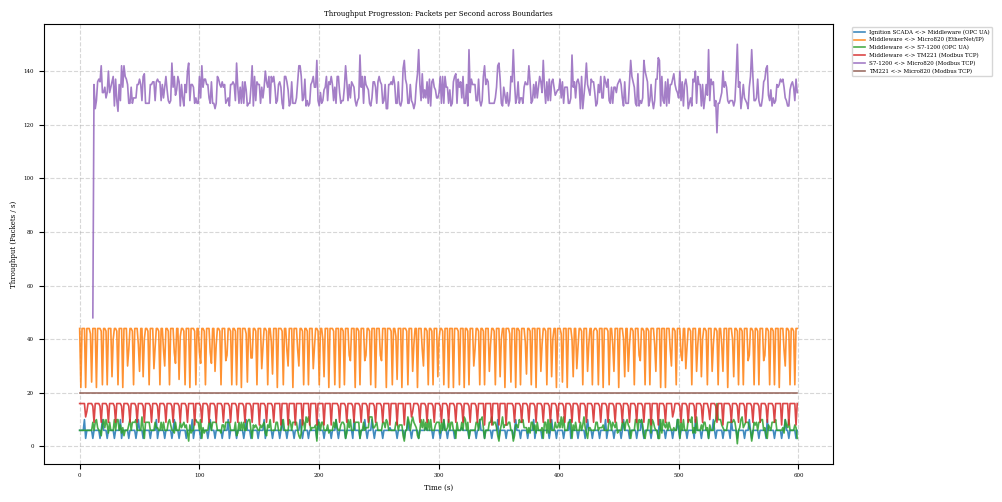

In [53]:
plt.figure(figsize=(10, 5))
for boundary, group in MATRIX_THROUGHPUT_DF.groupby("Boundary"):
    plt.plot(
        group["Time_Bin_Start_Sec"],
        group["Packets_per_Sec"],
        label=boundary,
        color=color_map[boundary],
        linewidth=1.2,
        alpha=0.85,
    )

plt.title("Throughput Progression: Packets per Second across Boundaries")
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Packets / s)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig("throughput_packets_per_sec.png", dpi=300)
plt.show()

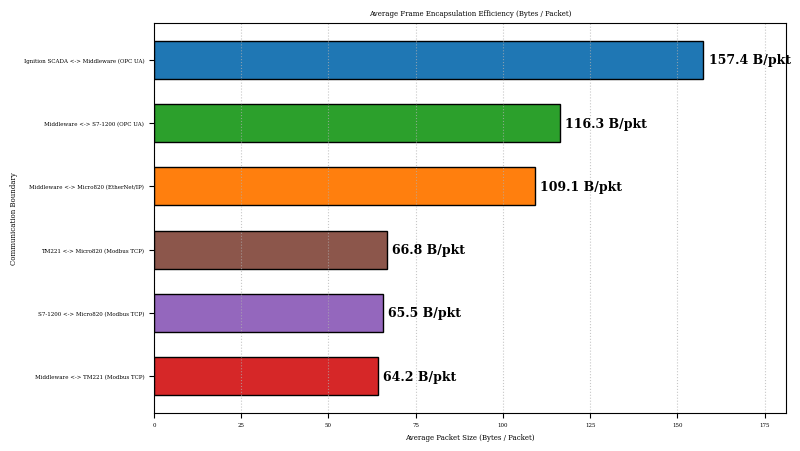

In [54]:
pkt_size_summary = (
    MATRIX_THROUGHPUT_DF.groupby(["Boundary", "Protocol"])["Avg_Packet_Size"]
    .mean()
    .reset_index()
    .sort_values(by="Avg_Packet_Size", ascending=True)
)

plt.figure(figsize=(8, 4.5))
bars = plt.barh(
    pkt_size_summary["Boundary"],
    pkt_size_summary["Avg_Packet_Size"],
    color=[color_map[b] for b in pkt_size_summary["Boundary"]],
    edgecolor="black",
    height=0.6,
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f} B/pkt",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
    )

plt.title("Average Frame Encapsulation Efficiency (Bytes / Packet)")
plt.xlabel("Average Packet Size (Bytes / Packet)")
plt.ylabel("Communication Boundary")
plt.xlim(0, max(pkt_size_summary["Avg_Packet_Size"]) * 1.15)
plt.grid(True, linestyle=":", axis="x", alpha=0.7)
plt.tight_layout()
plt.savefig("avg_packet_size_comparison.png", dpi=300)
plt.show()

In [60]:
boundary_order = (
    MATRIX_THROUGHPUT_DF.groupby("Boundary")["Bytes_per_Sec"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Color palette mapping
palette = sns.color_palette("tab10", n_colors=len(boundary_order))
color_map = dict(zip(boundary_order, palette))

C:\Users\chabz\AppData\Local\Temp\ipykernel_23276\2854865277.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


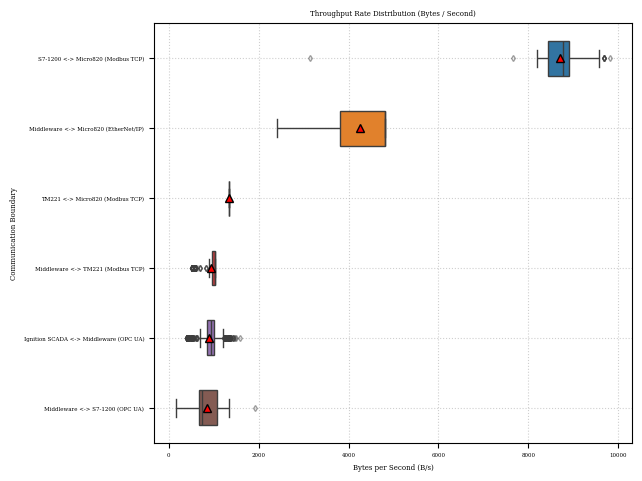

In [61]:

ax = sns.boxplot(
    data= MATRIX_THROUGHPUT_DF,
    x="Bytes_per_Sec",
    y="Boundary",
    order=boundary_order,
    palette=color_map,
    orient="h",
    width=0.5,
    showmeans=True,
    meanprops={"marker": "^","markerfacecolor": "red","markeredgecolor": "black","markersize": 6,},
    flierprops={"marker": "d", "markersize": 3, "alpha": 0.5})

plt.title("Throughput Rate Distribution (Bytes / Second)")
plt.xlabel("Bytes per Second (B/s)")
plt.ylabel("Communication Boundary")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig("throughput_bytes_per_sec_boxplot.png", dpi=300)
plt.show()

In [58]:
throughput_summary_df = (
    MATRIX_THROUGHPUT_DF.groupby(["Boundary", "Protocol"])
    .agg(
        Mean_Bps=("Bytes_per_Sec", "mean"),
        Peak_Bps=("Bytes_per_Sec", "max"),
        Mean_Pps=("Packets_per_Sec", "mean"),
        Peak_Pps=("Packets_per_Sec", "max"),
        Avg_Pkt_Size=("Avg_Packet_Size", "mean"),
    )
    .reset_index()
    .sort_values(by="Mean_Bps", ascending=False)
)

# Rename columns for LaTeX / paper representation
throughput_summary_df.columns = [
    "Communication Boundary",
    "Protocol",
    "Mean (B/s)",
    "Peak (B/s)",
    "Mean (p/s)",
    "Peak (p/s)",
    "Avg Packet Size (B/pkt)",
]

# Print Markdown & LaTeX formatted tables



--- MARKDOWN SUMMARY TABLE ---
| Communication Boundary                 | Protocol    |   Mean (B/s) |   Peak (B/s) |   Mean (p/s) |   Peak (p/s) |   Avg Packet Size (B/pkt) |
|:---------------------------------------|:------------|-------------:|-------------:|-------------:|-------------:|--------------------------:|
| S7-1200 <-> Micro820 (Modbus TCP)      | Modbus TCP  |      8707.30 |      9825.00 |       132.93 |       150.00 |                     65.50 |
| Middleware <-> Micro820 (EtherNet/IP)  | EtherNet/IP |      4249.31 |      4806.00 |        38.90 |        44.00 |                    109.11 |
| TM221 <-> Micro820 (Modbus TCP)        | Modbus TCP  |      1335.00 |      1335.00 |        20.00 |        20.00 |                     66.75 |
| Middleware <-> TM221 (Modbus TCP)      | Modbus TCP  |       943.19 |      1028.00 |        14.68 |        16.00 |                     64.23 |
| Ignition SCADA <-> Middleware (OPC UA) | OPC UA      |       906.03 |      1592.00 |         5.7

In [62]:
throughput_summary_df.to_csv(r"..\data\throughput_summary.csv")

In [63]:
throughput_summary_df

,Communication Boundary,Protocol,Mean (B/s),Peak (B/s),Mean (p/s),Peak (p/s),Avg Packet Size (B/pkt)
4,S7-1200 <-> Micro820 (Modbus TCP),Modbus TCP,8707.303905,9825.0,132.933786,150.0,65.500793
1,Middleware <-> Micro820 (EtherNet/IP),EtherNet/IP,4249.305000,4806.0,38.903333,44.0,109.114212
5,TM221 <-> Micro820 (Modbus TCP),Modbus TCP,1335.000000,1335.0,20.000000,20.0,66.750000
3,Middleware <-> TM221 (Modbus TCP),Modbus TCP,943.190000,1028.0,14.680000,16.0,64.227044
0,Ignition SCADA <-> Middleware (OPC UA),OPC UA,906.028333,1592.0,5.778333,10.0,157.403349
2,Middleware <-> S7-1200 (OPC UA),OPC UA,849.778333,1913.0,7.275000,16.0,116.288447
